# NASA C-MAPSS: EDA と RUL 予測ベースライン

航空機エンジンの多変量時系列から Remaining Useful Life（RUL、残存耐用サイクル）を予測します。

- **EDA**: データ品質、エンジン寿命、センサー分散、RULとの相関、劣化軌跡
- **検証設計**: エンジン単位の分割（同一エンジンが学習・検証をまたがない）
- **ベースライン**: 中央値予測、Ridge回帰、Random Forest
- **最終評価**: FD001の公式test/RULデータで RMSE・MAE・R²・NASA score を算出

学習用RULはC-MAPSSで一般的なpiecewise-linear targetとして125サイクルで上限を設定します。公式テスト評価では提供されたRULをそのまま使います。

> **用語メモ**: RULは「故障まであと何サイクル使えるか」です。たとえばRUL=30なら故障まで残り30サイクルです。EDAは、モデルを作る前にデータの特徴や異常をグラフ・集計で調べる作業です。

In [1]:
# Pathは、Windowsのフォルダやファイルの場所を扱いやすくする道具です。
from pathlib import Path
import warnings

# joblibはモデル保存、matplotlib/seabornはグラフ描画に使います。
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")

# 乱数を固定すると、何度実行しても同じ分割・同じ結果を再現できます。
RANDOM_STATE = 42
# 故障から遠い健全期間は、まとめてRUL=125として扱います。
RUL_CAP = 125
DATA_DIR = Path("CMAPSSData")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
assert DATA_DIR.exists(), "リポジトリ直下から実行してください。"

## 1. データ読み込み

各行は1エンジンの1サイクルのスナップショットです。列はエンジンID、サイクル、3つの運転条件、21個のセンサー値です。

In [ ]:
# 元データには列名がないため、仕様書に合わせて列名を用意します。
SETTING_COLS = [f"setting_{i}" for i in range(1, 4)]
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
COLUMNS = ["unit_id", "cycle", *SETTING_COLS, *SENSOR_COLS]

def load_split(dataset):
    # 1個以上の空白を列の区切りとして読み込みます。
    train = pd.read_csv(DATA_DIR / f"train_{dataset}.txt", sep=r"\s+", header=None, names=COLUMNS)
    test = pd.read_csv(DATA_DIR / f"test_{dataset}.txt", sep=r"\s+", header=None, names=COLUMNS)
    test_rul = pd.read_csv(DATA_DIR / f"RUL_{dataset}.txt", header=None, names=["RUL"])
    # RULファイルは1行目がunit_id=1、2行目がunit_id=2、…の順です。
    test_rul.index = np.arange(1, len(test_rul) + 1)
    test_rul.index.name = "unit_id"
    return train, test, test_rul

def add_rul(df, cap=None):
    out = df.copy()
    # 最終サイクル200、現在150なら、RULは200-150=50です。
    max_cycle = out.groupby("unit_id")["cycle"].transform("max")
    out["RUL_raw"] = max_cycle - out["cycle"]
    out["RUL"] = out["RUL_raw"].clip(upper=cap) if cap else out["RUL_raw"]
    return out

train, test, test_rul = load_split("FD001")
train = add_rul(train, cap=RUL_CAP)
train.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL_raw,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,125


## 2. データ概要と品質チェック

In [3]:
# 4データセットの大きさを一覧にして、読み込み漏れがないか確認します。
overview_rows = []
for name in ["FD001", "FD002", "FD003", "FD004"]:
    tr, te, truth = load_split(name)
    overview_rows.append({
        "dataset": name, "train_rows": len(tr), "train_units": tr.unit_id.nunique(),
        "test_rows": len(te), "test_units": te.unit_id.nunique(), "provided_test_RUL": len(truth),
    })
display(pd.DataFrame(overview_rows).set_index("dataset"))

# 欠損値や重複行があると学習結果を歪めるため、件数を確認します。
quality = pd.DataFrame({
    "rows": [len(train), len(test)],
    "units": [train.unit_id.nunique(), test.unit_id.nunique()],
    "missing_values": [int(train.isna().sum().sum()), int(test.isna().sum().sum())],
    "duplicate_rows": [int(train.duplicated().sum()), int(test.duplicated().sum())],
}, index=["train_FD001", "test_FD001"])
display(quality)

,train_rows,train_units,test_rows,test_units,provided_test_RUL
dataset,,,,,
FD001,20631,100,13096,100,100
FD002,53759,260,33991,259,259
FD003,24720,100,16596,100,100
FD004,61249,249,41214,248,248


,rows,units,missing_values,duplicate_rows
train_FD001,20631,100,0,0
test_FD001,13096,100,0,0


,train_lifetime,test_observed_cycles
count,100.00,100.00
mean,206.31,130.96
std,46.34,53.59
min,128.00,31.00
25%,177.00,88.75
50%,199.00,133.50
75%,229.25,164.25
max,362.00,303.00


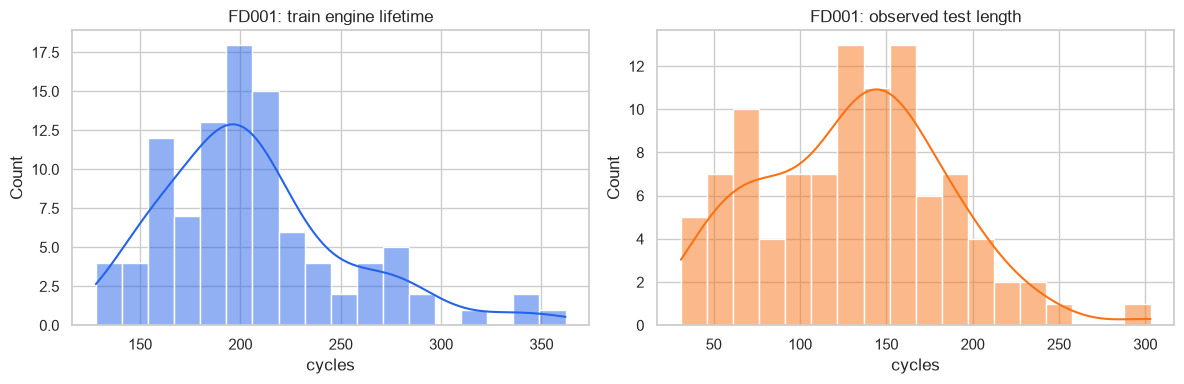

In [4]:
# unit_idごとの最大cycleが、そのエンジンの観測された寿命です。
train_life = train.groupby("unit_id")["cycle"].max().rename("lifetime")
test_observed = test.groupby("unit_id")["cycle"].max().rename("observed_cycles")
display(pd.concat([
    train_life.describe().rename("train_lifetime"),
    test_observed.describe().rename("test_observed_cycles")
], axis=1).round(2))

# ヒストグラムで、寿命や観測期間の分布を確認します。
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_life, bins=18, kde=True, ax=axes[0], color="#2563eb")
axes[0].set(title="FD001: train engine lifetime", xlabel="cycles")
sns.histplot(test_observed, bins=18, kde=True, ax=axes[1], color="#f97316")
axes[1].set(title="FD001: observed test length", xlabel="cycles")
plt.tight_layout(); plt.show()

## 3. センサーの探索

分散がほぼゼロの列はFD001では情報を持たないためモデルから除外します。残ったセンサーについてRULとのPearson相関と代表的な劣化軌跡を確認します。

near-constant sensors (6): ['sensor_16', 'sensor_5', 'sensor_1', 'sensor_10', 'sensor_18', 'sensor_19']
active sensors (15): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


,mean,std,n_unique,corr_with_RUL,abs_corr_with_RUL
sensor_11,47.54117,0.26709,159,-0.77523,0.77523
sensor_4,1408.93378,9.00060,4051,-0.75716,0.75716
sensor_12,521.41347,0.73755,427,0.74887,0.74887
sensor_7,553.36771,0.88509,513,0.73302,0.73302
sensor_15,8.44215,0.03751,1918,-0.72086,0.72086
sensor_21,23.28971,0.10825,4745,0.70733,0.70733
sensor_20,38.81627,0.18075,120,0.70463,0.70463
sensor_17,393.21065,1.54876,13,-0.68083,0.68083
sensor_2,642.68093,0.50005,310,-0.67846,0.67846
sensor_3,1590.52312,6.13115,3012,-0.65503,0.65503


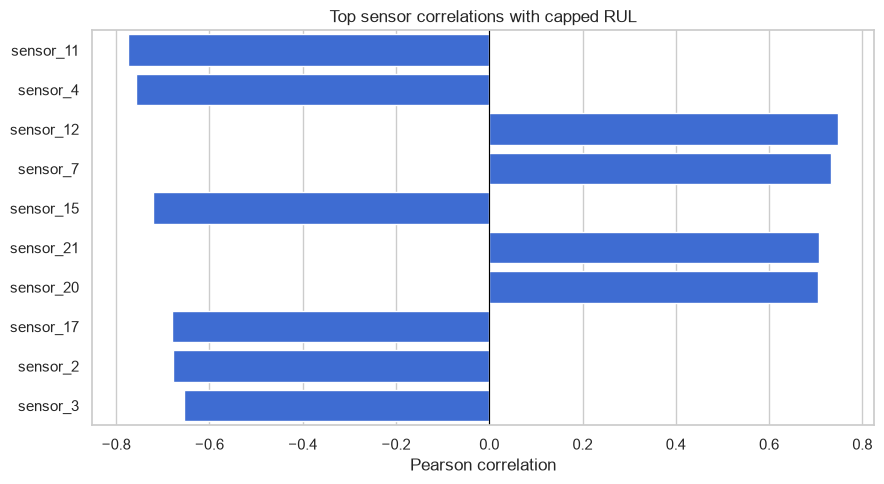

In [5]:
# 標準偏差(std)が0に近い列は値がほぼ変わらず、予測材料になりにくい列です。
sensor_stats = pd.DataFrame({
    "mean": train[SENSOR_COLS].mean(), "std": train[SENSOR_COLS].std(),
    "n_unique": train[SENSOR_COLS].nunique(),
    "corr_with_RUL": train[SENSOR_COLS].corrwith(train["RUL"]),
})
sensor_stats["abs_corr_with_RUL"] = sensor_stats.corr_with_RUL.abs()
sensor_stats = sensor_stats.sort_values("abs_corr_with_RUL", ascending=False)
# 一定値に近いセンサーを除き、残りを学習に使います。
constant_sensors = sensor_stats.index[sensor_stats["std"] <= 1e-8].tolist()
active_sensors = [c for c in SENSOR_COLS if c not in constant_sensors]
print(f"near-constant sensors ({len(constant_sensors)}): {constant_sensors}")
print(f"active sensors ({len(active_sensors)}): {active_sensors}")
display(sensor_stats.round(5))

# 相関係数は-1〜1で、絶対値が1に近いほどRULとの関係が強い値です。
top_corr = sensor_stats.loc[active_sensors].nlargest(10, "abs_corr_with_RUL")
plt.figure(figsize=(9, 5))
sns.barplot(data=top_corr.reset_index(), x="corr_with_RUL", y="index", color="#2563eb")
plt.axvline(0, color="black", linewidth=.8)
plt.title("Top sensor correlations with capped RUL")
plt.xlabel("Pearson correlation"); plt.ylabel(""); plt.tight_layout(); plt.show()

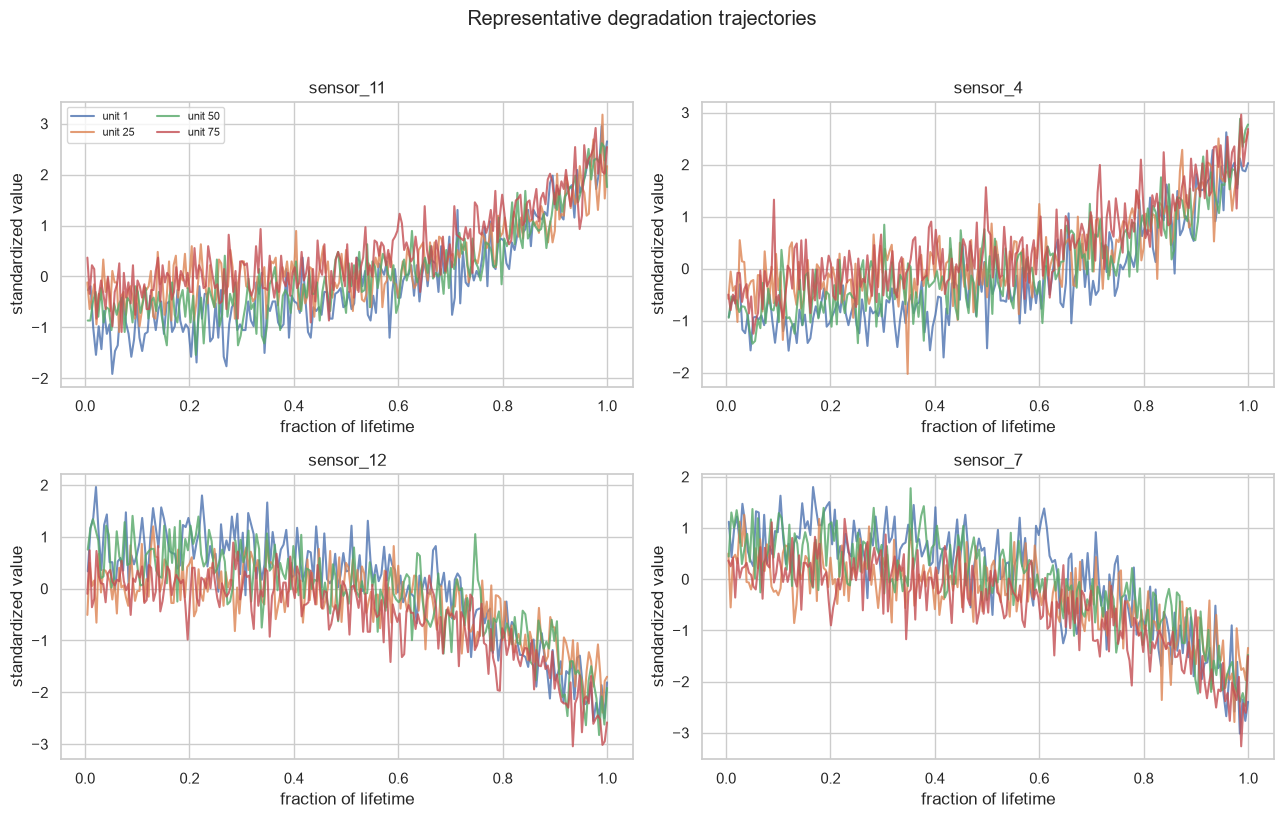

In [6]:
# 相関が強かった4センサーを、代表的な4エンジンについて描きます。
selected_for_plot = top_corr.index[:4].tolist()
example_units = [1, 25, 50, 75]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for sensor, ax in zip(selected_for_plot, axes.flat):
    for unit in example_units:
        part = train.loc[train.unit_id == unit]
        # 寿命の違うエンジンを比べるため、横軸を0〜1にそろえます。
        x = part.cycle / part.cycle.max()
        # センサーごとの単位・桁の違いをなくすため標準化します。
        y = (part[sensor] - train[sensor].mean()) / train[sensor].std()
        ax.plot(x, y, alpha=.8, label=f"unit {unit}")
    ax.set(title=sensor, xlabel="fraction of lifetime", ylabel="standardized value")
axes[0, 0].legend(ncol=2, fontsize=8)
fig.suptitle("Representative degradation trajectories", y=1.02)
plt.tight_layout(); plt.show()

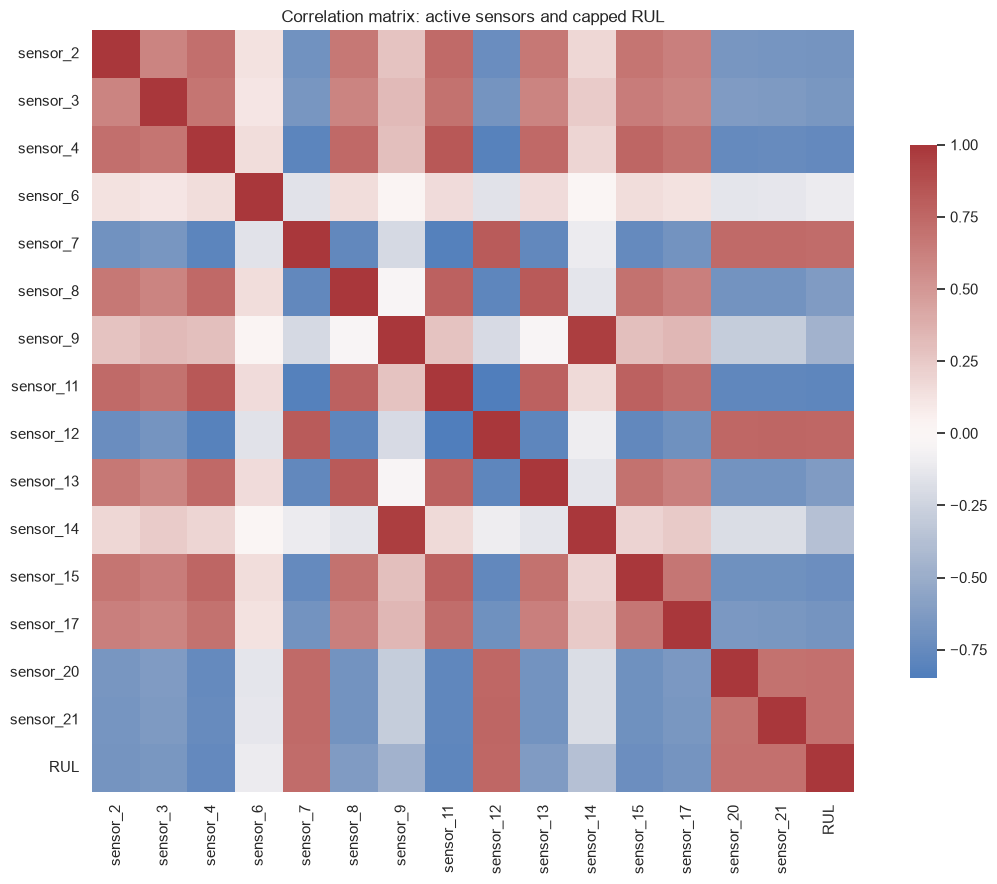

In [7]:
# ヒートマップは各センサー同士とRULの相関を色で一覧表示します。
plt.figure(figsize=(12, 9))
sns.heatmap(train[active_sensors + ["RUL"]].corr(), cmap="vlag", center=0,
            square=True, cbar_kws={"shrink": .7})
plt.title("Correlation matrix: active sensors and capped RUL")
plt.tight_layout(); plt.show()

## 4. 特徴量と検証設計

各エンジン内で現在値に加えて、直近5サイクルの平均・標準偏差・変化量を作ります。分割は行単位ではなくエンジンID単位です。検証エンジンの寿命50%、70%、90%の位置を擬似的な観測終了点として評価します。

In [8]:
def add_features(df, sensors, window=5):
    out = df.sort_values(["unit_id", "cycle"]).copy()
    # エンジンごとに計算し、別エンジンの値が混ざるのを防ぎます。
    grouped = out.groupby("unit_id", sort=False)
    for col in sensors:
        # 直近5サイクルの平均で、短期的なノイズをならします。
        out[f"{col}_roll_mean_{window}"] = grouped[col].transform(
            lambda s: s.rolling(window, min_periods=1).mean())
        # 直近5サイクルの標準偏差で、最近の値の揺れを表します。
        out[f"{col}_roll_std_{window}"] = grouped[col].transform(
            lambda s: s.rolling(window, min_periods=1).std().fillna(0))
        # 1サイクル前との差で、変化方向と変化量を表します。
        out[f"{col}_delta"] = grouped[col].diff().fillna(0)
    return out

train_fe = add_features(train, active_sensors)
test_fe = add_features(test, active_sensors)
base = ["cycle", *SETTING_COLS, *active_sensors]
feature_cols = [c for c in train_fe if c in base or c.endswith(("_roll_mean_5", "_roll_std_5", "_delta"))]

# エンジンを80台の学習用と20台の検証用に分け、データリークを防ぎます。
rng = np.random.default_rng(RANDOM_STATE)
all_units = train_fe.unit_id.unique(); rng.shuffle(all_units)
split_at = int(len(all_units) * .8)
train_units, val_units = all_units[:split_at], all_units[split_at:]
fit_rows = train_fe[train_fe.unit_id.isin(train_units)].copy()
val_rows = train_fe[train_fe.unit_id.isin(val_units)].copy()

# 寿命50%・70%・90%時点を、故障前で止まった擬似testデータにします。
endpoint_parts = []
for fraction in (.5, .7, .9):
    lifetimes = val_rows.groupby("unit_id").cycle.max()
    cutoffs = np.floor(lifetimes * fraction).astype(int).clip(lower=1)
    keys = pd.MultiIndex.from_arrays([cutoffs.index, cutoffs.values])
    mask = val_rows.set_index(["unit_id", "cycle"]).index.isin(keys)
    part = val_rows.loc[mask].copy(); part["cutoff_fraction"] = fraction
    endpoint_parts.append(part)
val_endpoints = pd.concat(endpoint_parts, ignore_index=True)

print(f"fit engines={len(train_units)}, validation engines={len(val_units)}")
print(f"features={len(feature_cols)}, fit rows={len(fit_rows):,}, pseudo-test endpoints={len(val_endpoints)}")

fit engines=80, validation engines=20
features=64, fit rows=16,527, pseudo-test endpoints=60


## 5. ベースライン学習と検証

In [9]:
def nasa_score(y_true, y_pred):
    # 予測-正解が正なら、実際より長く使えると危険側に予測しています。
    d = np.asarray(y_pred) - np.asarray(y_true)
    return float(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum())

def regression_metrics(y_true, y_pred):
    # RMSE/MAEは小さいほど良く、R2は1に近いほど良い指標です。
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** .5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "NASA_score": nasa_score(y_true, y_pred),
    }

# Dummy、直線モデル、非線形モデルの3種類を同じ条件で比較します。
models = {
    # Dummyは常に中央値を返すだけの、最低限超えるべき基準です。
    "Dummy median": DummyRegressor(strategy="median"),
    # Ridgeは入力とRULの直線的な関係を学ぶシンプルなモデルです。
    "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    # Random Forestは多数の決定木を組み合わせ、曲線的な関係も学べます。
    "Random Forest": RandomForestRegressor(
        n_estimators=250, min_samples_leaf=3, max_features=.7,
        n_jobs=-1, random_state=RANDOM_STATE),
}
validation_results = []
for name, model in models.items():
    # fitで学習し、predictで未使用の検証データを予測します。
    model.fit(fit_rows[feature_cols], fit_rows["RUL"])
    pred = np.clip(model.predict(val_endpoints[feature_cols]), 0, RUL_CAP)
    validation_results.append({"model": name, **regression_metrics(val_endpoints.RUL_raw, pred)})
validation_metrics = pd.DataFrame(validation_results).set_index("model").sort_values("RMSE")
display(validation_metrics.round(3))

,RMSE,MAE,R2,NASA_score
model,,,,
Random Forest,20.737,14.565,0.683,885.902
Ridge,23.237,18.196,0.602,965.015
Dummy median,55.138,47.150,-1.239,82960.537


selected model: Random Forest


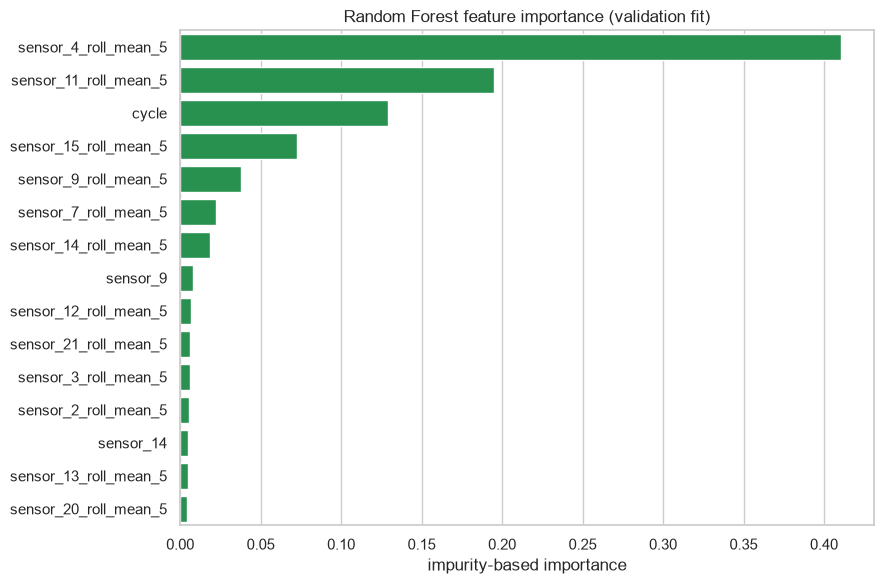

In [10]:
# 検証RMSEが最も小さいモデルを最終モデルとして選びます。
best_name = validation_metrics.index[0]
best_model = models[best_name]
print(f"selected model: {best_name}")
if best_name == "Random Forest":
    # importanceは、予測に多く使われた特徴量の目安です。
    importance = pd.Series(best_model.feature_importances_, index=feature_cols).nlargest(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=importance.values, y=importance.index, color="#16a34a")
    plt.title("Random Forest feature importance (validation fit)")
    plt.xlabel("impurity-based importance"); plt.ylabel(""); plt.tight_layout(); plt.show()

## 6. 全trainで再学習し、公式testを評価

検証で最良だったモデルをFD001の全train行で再学習します。testは各エンジンの最終観測行だけを取り出し、提供されたRULと比較します。

In [11]:
# モデル選択後、使える全trainデータでもう一度学習します。
best_model.fit(train_fe[feature_cols], train_fe["RUL"])
# testでは、各エンジンの最後に観測された1行を予測対象にします。
last_idx = test_fe.groupby("unit_id").cycle.idxmax()
test_endpoints = test_fe.loc[last_idx].sort_values("unit_id").copy()
assert test_endpoints.unit_id.tolist() == test_rul.index.tolist()

# RULが負や125超にならないよう、予測値を範囲内へ収めます。
test_pred = np.clip(best_model.predict(test_endpoints[feature_cols]), 0, RUL_CAP)
y_test = test_rul.RUL.to_numpy()
test_metrics = pd.DataFrame([{
    "dataset": "FD001 official test", "model": best_name,
    **regression_metrics(y_test, test_pred)
}]).set_index(["dataset", "model"])
display(test_metrics.round(3))

predictions = pd.DataFrame({
    "unit_id": test_endpoints.unit_id.to_numpy(),
    "last_observed_cycle": test_endpoints.cycle.to_numpy(),
    "RUL_true": y_test, "RUL_pred": test_pred, "error": test_pred - y_test,
})
display(predictions.head(10).round(2))

,,RMSE,MAE,R2,NASA_score
dataset,model,,,,
FD001 official test,Random Forest,18.695,13.632,0.798,623.198


,unit_id,last_observed_cycle,RUL_true,RUL_pred,error
0,1,31,112,123.03,11.03
1,2,49,98,119.64,21.64
2,3,126,69,47.74,-21.26
3,4,106,82,77.39,-4.61
4,5,98,91,95.63,4.63
5,6,105,93,92.25,-0.75
6,7,160,91,96.96,5.96
7,8,166,95,71.00,-24.00
8,9,55,111,120.55,9.55
9,10,192,96,110.76,14.76


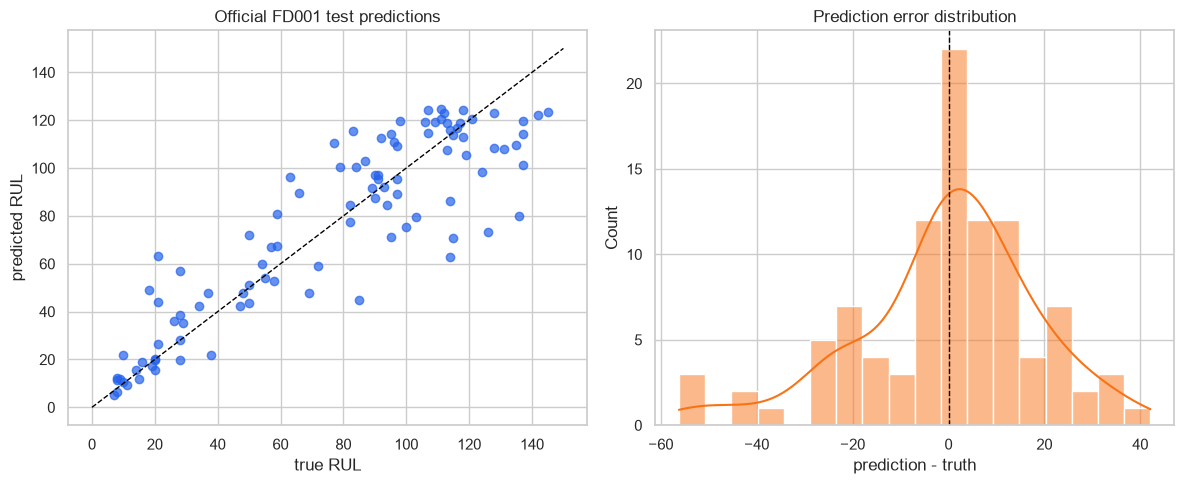

In [12]:
# 左は正解と予測の散布図、右は予測誤差の分布です。
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, test_pred, alpha=.7, color="#2563eb")
limit = max(y_test.max(), test_pred.max()) + 5
axes[0].plot([0, limit], [0, limit], "--", color="black", linewidth=1)
axes[0].set(xlabel="true RUL", ylabel="predicted RUL", title="Official FD001 test predictions")
sns.histplot(predictions.error, bins=18, kde=True, ax=axes[1], color="#f97316")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(xlabel="prediction - truth", title="Prediction error distribution")
plt.tight_layout(); plt.show()

## 7. 成果物の保存

In [13]:
# CSVはExcelでも確認でき、joblibは学習済みモデルを再利用できます。
predictions.to_csv(ARTIFACT_DIR / "fd001_test_predictions.csv", index=False)
test_metrics.reset_index().to_csv(ARTIFACT_DIR / "fd001_metrics.csv", index=False)
joblib.dump({
    "model": best_model, "feature_cols": feature_cols,
    "active_sensors": active_sensors, "rul_cap": RUL_CAP,
}, ARTIFACT_DIR / "fd001_baseline_model.joblib", compress=3)

print("saved:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    print(f"- {path} ({path.stat().st_size:,} bytes)")

saved:
- artifacts\fd001_baseline_model.joblib (25,084,428 bytes)
- artifacts\fd001_metrics.csv (147 bytes)
- artifacts\fd001_test_predictions.csv (4,883 bytes)


## 8. 読み取り上の注意と次の改善候補

- FD001は運転条件1種・故障モード1種なので、FD002/FD004へそのまま一般化できるとは限りません。
- RUL上限125は「初期の健全区間を同じ状態として扱う」仮定です。検証で上限値を調整できます。
- NASA scoreは過大予測（実際より長く使えると予測）を強く罰します。RMSEだけでなく両方を確認します。
- 次の改善候補は、運転条件別の正規化、勾配ブースティング、時系列窓を入力する1D-CNN/LSTM、全FD系列を跨ぐ評価です。